In [100]:
## Classification 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle

### FUNCTIONS 

# dimensionality reduction
def pca_function(x_train,x_test,components):
    pca = PCA(n_components=components)
    x_train = pca.fit_transform(x_train)  # PCA is unsupervised learning - so compute only X 
    x_test = pca.transform(x_test)
    explained_variance=pca.explained_variance_ratio_
    return explained_variance

# tran test split and standardization 
def split_scaler(indep_x,dep_y):
    x_train,x_test,y_train,y_test = train_test_split(indep_x,dep_y,test_size=0.20,random_state=0)
    # standardization
    sc=StandardScaler()
    x_train=sc.fit_transform(x_train)
    x_test=sc.transform(x_test)
    return  x_train,x_test,y_train,y_test

# model prediction & evaluation 
def cm_pred_eval(classifier,x_test):
    # prediction
    y_pred=classifier.predict(x_test)
    # confusion matrix
    from sklearn.metrics import confusion_matrix
    cm=confusion_matrix(y_test,y_pred)
    # classification report 
    from sklearn.metrics import classification_report
    classi_report=classification_report(y_test,y_pred)
    # accuracy 
    from sklearn.metrics import accuracy_score
    accuracy=accuracy_score(y_test,y_pred)
    return classifier,accuracy,cm,classi_report,x_test,y_test

### --------------- classification algortihms -----------------------------
# logistic regression 
def logistic(x_train,y_train,x_test):
    # model creation
    from sklearn.linear_model import LogisticRegression
    classifier=LogisticRegression(random_state=0)
    classifier.fit(x_train,y_train)
    # model prediction & evaluation
    classifier,accuracy,cm,classi_report,x_test,y_test = cm_pred_eval(classifier,x_test)
    return classifier,accuracy,cm,classi_report,x_test,y_test

# KNN 
def knn(x_train,y_train,x_test):
    # model creation
    from sklearn.neighbors import KNeighborsClassifier
    classifier=KNeighborsClassifier(n_neighbors=5,p=2, metric='minkowski')
    classifier.fit(x_train,y_train)
    # model prediction & evaluation
    classifier,accuracy,cm,classi_report,x_test,y_test = cm_pred_eval(classifier,x_test)
    return classifier,accuracy,cm,classi_report,x_test,y_test

# SVM - linear 
def svm_linear(x_train,y_train,x_test):
    # model creation
    from sklearn.svm import SVC
    classifier=SVC(kernel='linear',random_state=0)
    classifier.fit(x_train,y_train)
    # model prediction & evaluation
    classifier,accuracy,cm,classi_report,x_test,y_test = cm_pred_eval(classifier,x_test)
    return classifier,accuracy,cm,classi_report,x_test,y_test

# SVM - Non linear 
def svm_nonlinear(x_train,y_train,x_test):
    # model creation
    from sklearn.svm import SVC
    classifier=SVC(kernel='rbf',random_state=0)
    classifier.fit(x_train,y_train)
    # model prediction & evaluation
    classifier,accuracy,cm,classi_report,x_test,y_test = cm_pred_eval(classifier,x_test)
    return classifier,accuracy,cm,classi_report,x_test,y_test

# navie bayes
def naive(x_train,y_train,x_test):
    # model creation 
    from sklearn.naive_bayes import GaussianNB
    classifier=GaussianNB()
    classifier.fit(x_train,y_train)
    # model prediction & evaluation
    classifier,accuracy,cm,classi_report,x_test,y_test = cm_pred_eval(classifier,x_test)
    return classifier,accuracy,cm,classi_report,x_test,y_test

# decision tree
def decision_tree(x_train,y_train,x_test):
     # model creation 
    from sklearn.tree import DecisionTreeClassifier
    classifier=DecisionTreeClassifier(criterion='entropy',random_state=0)
    classifier.fit(x_train,y_train)
    # model prediction & evaluation
    classifier,accuracy,cm,classi_report,x_test,y_test = cm_pred_eval(classifier,x_test)
    return classifier,accuracy,cm,classi_report,x_test,y_test

# random forest
def random_forest(x_train,y_train,x_test):
     # model creation 
    from sklearn.ensemble import RandomForestClassifier
    classifier=RandomForestClassifier(n_estimators=10,criterion='entropy',random_state=0)
    classifier.fit(x_train,y_train)
    # model prediction & evaluation
    classifier,accuracy,cm,classi_report,x_test,y_test = cm_pred_eval(classifier,x_test)
    return classifier,accuracy,cm,classi_report,x_test,y_test


## ------------ final table for comparision 

    

def pca_classifi_DF(components,x_train,x_test,y_train):
    dataframe=pd.DataFrame(index=components)
    for i in components:
        explained_variance = pca_function(x_train,x_test,i)
        
        # algorithms 
        classifier,accuracy,cm,classi_report,x_test,y_test=logistic(x_train,y_train,x_test)
        dataframe.loc[i,"logistic"]=accuracy
        classifier,accuracy,cm,classi_report,x_test,y_test=knn(x_train,y_train,x_test)
        dataframe.loc[i,"knn"]=accuracy
        classifier,accuracy,cm,classi_report,x_test,y_test=svm_linear(x_train,y_train,x_test)
        dataframe.loc[i,"svm_l"]=accuracy
        classifier,accuracy,cm,classi_report,x_test,y_test=svm_nonlinear(x_train,y_train,x_test)
        dataframe.loc[i,"svm_nl"]=accuracy
        classifier,accuracy,cm,classi_report,x_test,y_test=naive(x_train,y_train,x_test)
        dataframe.loc[i,"naive"]=accuracy
        classifier,accuracy,cm,classi_report,x_test,y_test=decision_tree(x_train,y_train,x_test)
        dataframe.loc[i,"decision tree"]=accuracy
        classifier,accuracy,cm,classi_report,x_test,y_test=random_forest(x_train,y_train,x_test)
        dataframe.loc[i,"random forest"]=accuracy

    return dataframe



In [101]:
### main program 

data_original = pd.read_csv('preprocessed_CKD.csv')
data_ckd= data_original
data_ckd

data_ckd=pd.get_dummies(data_ckd,drop_first=True,dtype=int)
data_ckd.head()

# ip op split 

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,...,dm_yes,cad_unknown,cad_yes,appet_poor,appet_unknown,pe_unknown,pe_yes,ane_unknown,ane_yes,classification_notckd
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,138.0,4.4,...,1,0,0,0,0,0,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,121.0,18.0,0.8,138.0,4.4,...,0,0,0,0,0,0,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,138.0,4.4,...,1,0,0,1,0,0,0,0,1,0
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,...,0,0,0,1,0,0,1,0,1,0
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,138.0,4.4,...,0,0,0,0,0,0,0,0,0,0


In [112]:
indep_x=data_ckd.drop('classification_notckd',axis=1)
dep_y = data_ckd['classification_notckd']

# with standardization 
x_train,x_test,y_train,y_test=split_scaler(indep_x,dep_y) 
# print(x_train,x_test,y_train,y_test)

# train & test split without standardization 
# x_train,x_test,y_train,y_test = train_test_split(indep_x,dep_y,test_size=0.20,random_state=0)

print(x_train.shape)
print(x_test.shape)

# PCA function calling 
components = range(2,15)  # only 2 components --> n_components == min(n_samples, n_features)  -->  [ min(2,27) -> 2 ]
result = pca_classifi_DF(components,x_train,x_test,y_train)
result

(320, 34)
(80, 34)


,logistic,knn,svm_l,svm_nl,naive,decision tree,random forest
2,0.9875,0.9875,1.0,1.0,0.9875,1.0,1.0
3,0.9875,0.9875,1.0,1.0,0.9875,1.0,1.0
4,0.9875,0.9875,1.0,1.0,0.9875,1.0,1.0
5,0.9875,0.9875,1.0,1.0,0.9875,1.0,1.0
6,0.9875,0.9875,1.0,1.0,0.9875,1.0,1.0
7,0.9875,0.9875,1.0,1.0,0.9875,1.0,1.0
8,0.9875,0.9875,1.0,1.0,0.9875,1.0,1.0
9,0.9875,0.9875,1.0,1.0,0.9875,1.0,1.0
10,0.9875,0.9875,1.0,1.0,0.9875,1.0,1.0
11,0.9875,0.9875,1.0,1.0,0.9875,1.0,1.0


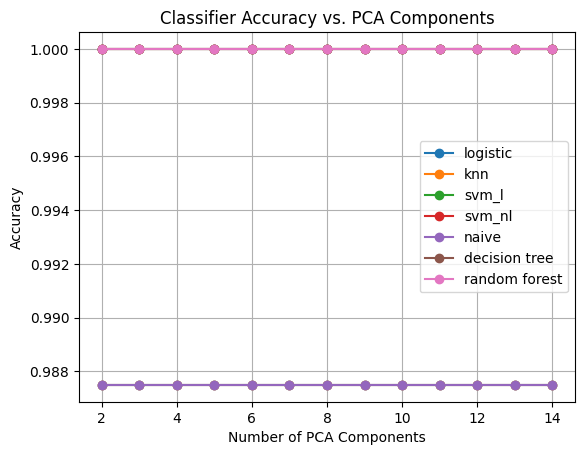

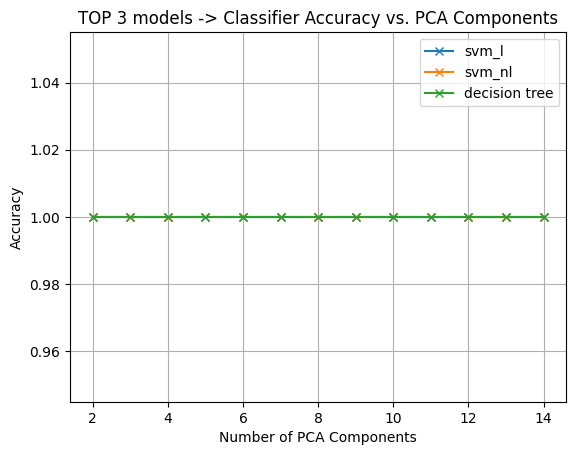

In [113]:
import matplotlib.pyplot as plt

# Plotting accuracy vs. components
for model in result.columns:
    plt.plot(result.index, result[model], label=model, marker='o')

plt.xlabel("Number of PCA Components")
plt.ylabel("Accuracy")
plt.title("Classifier Accuracy vs. PCA Components")
plt.legend()
plt.grid(True)
plt.show()


top_models = result.max().sort_values(ascending=False).head(3)
top_models
# Plotting accuracy vs. components
for model in top_models.index:
    plt.plot(result.index, result[model], label=model, marker='x')

plt.xlabel("Number of PCA Components")
plt.ylabel("Accuracy")
plt.title("TOP 3 models -> Classifier Accuracy vs. PCA Components")
plt.legend()
plt.grid(True)
plt.show()